# Create Images of Drop Ship Sprites

In [11]:
from IPython.display import display, HTML
display(HTML("<style>.container { width:60% !important; }</style>"))

Load in the sprite data

In [12]:
import re
from colors_map import *

sprites_files = ["uridium/src/dropship_sprites.asm"]
sprites_data = {}
sprites_bytes = {}
sprites_ram = {}
sprites_offset = {}
sprite_orientation = {}
sprite_ram = 0x4000
for sprites_file in sprites_files:
    input_file = open(sprites_file,'r')
    sprite_data = []
    sprite_bytes = ""
    for l in input_file.readlines():
        if "SPRITE" in l:
            if sprite_data:
                sprites_data[sprite_name] = sprite_data
                sprites_bytes[sprite_name] = sprite_bytes
                sprites_ram[sprite_name] = hex(sprite_ram)[2:].upper()
                sprite_ram += 0x40
            sprite_name = l[22:36].strip()
            sprite_orientation[sprite_name] = (l[42:45],l[51:54],l[60:63],)
            sprites_offset[sprite_name] = l[18:20]
            sprite_data = []
            sprite_bytes = ""
            continue

        m = re.findall(r"[0-1]{24}",l)
        if not m:
            continue
        bits = m[0]
        sprite_line = []
        for i in range(0,23,2):
            bitpair = bits[i:i+2]
            sprite_line += [bitpair]
            sprite_line += [bitpair]
        sprite_data += [sprite_line]
        sprite_bytes += l[10:21]+'\n'
    if sprite_data:
        sprites_data[sprite_name] = sprite_data
        sprites_bytes[sprite_name] = sprite_bytes
        sprites_ram[sprite_name] = hex(sprite_ram)[2:].upper()

Function for actually drawing the sprite

In [109]:
from PIL import Image, ImageDraw, ImageColor, ImageFont


def paintSprite(sprite_data, colors, verticalExpand=False, transparentBackground=False):
    verticalExpansion = 2 if verticalExpand else 1
    SPRITE_COLS = 24
    SPRITE_ROWS = 21 * verticalExpansion
    CELL_WIDTH = 40
    CELL_HEIGHT = 40
    
    (background, background_text), (multicol0, multicol0_text), (multicol1,multicol1_text), (color, color_text) = colors
    colormap = {
        "00": background,
        "01": multicol0,
        "10": color,
        "11": multicol1,
    }
    text_colormap = {
        "00": background_text,
        "01": multicol0_text,
        "10": color_text,
        "11": multicol1_text,
    }
    
    image_width = CELL_WIDTH*SPRITE_COLS
    image_height = CELL_HEIGHT*SPRITE_ROWS
    img = Image.new( 'RGBA', (image_width+1, image_height+1))
    draw = ImageDraw.Draw(img)

    fnt = ImageFont.truetype("RobotoMono-Light.ttf", 40)
    bit_array = sprite_data
    if verticalExpand:
        expanded_bit_array = []
        for a in bit_array:
            expanded_bit_array += [a,a]
        bit_array = expanded_bit_array
    
    # Remember that each bitpair in the bit_array is duplicated.
    # e.g. 01 appears as 01,01 so that we can treat each element as
    # a single bit.
    for y, l in enumerate(bit_array):
        for x,bit in enumerate(l):
            if bit == "00" and transparentBackground:
                continue
            pixel_color = ImageColor.getrgb(c64_to_rgb[colormap[bit]])
            X = x * CELL_WIDTH
            Y = y * CELL_HEIGHT
            draw.rectangle((X, Y, X+CELL_WIDTH, Y+CELL_HEIGHT), 
                           fill=pixel_color, outline="black")
            b = bit[(x%2)] # Get the correct side of the bitpair
            draw.text((X+10, Y-8), b, font=fnt, fill=text_colormap[bit])
    return img


In [14]:
byte_literals = """.BYTE
.BYTE 
.BYTE 
.BYTE 
.BYTE 
.BYTE 
.BYTE 
.BYTE 
.BYTE 
.BYTE 
.BYTE 
.BYTE 
.BYTE 
.BYTE 
.BYTE 
.BYTE 
.BYTE 
.BYTE 
.BYTE 
.BYTE 
.BYTE 
"""

colors = (
    # cell color, text color
    ("c64_black", "white"),
    ("c64_gray1", "darkgray"),
    ("c64_white", "gray"),
    ("c64_gray3", "white"),
)
sprite_name = "MANTA_LEFT_9"

def generateSpriteDiagram(sprite_name, entry_num):
    sprite_data = sprites_data[sprite_name]
    sprite_bytes = sprites_bytes[sprite_name]
    sprite_ram = sprites_ram[sprite_name]
    sprite_offset = sprites_offset[sprite_name]
    
    sprite_img = paintSprite(sprite_data, colors)

    img = Image.new('RGBA', (1530,900))
    draw = ImageDraw.Draw(img)
    draw.rectangle([(0,0),img.size], fill = "white")

    # Sprite label
    label_text = f"URIDIUM/DROPSHIP/{('0'+str(entry_num))[-2:]}"
    label_fnt_size = 35
    label_fnt = ImageFont.truetype("Eurostile.ttf", label_fnt_size)
    txt_width = len(label_text) * label_fnt_size
    txt = Image.new('RGBA', (txt_width, label_fnt_size))
    draw = ImageDraw.Draw(txt)
    draw.rectangle([(0,0), txt.size], fill = "white")
    draw.text((0, 0), label_text, font=label_fnt, fill="black")
    label = txt.rotate(90,  expand=1)
    img.paste(label, (35,184))

    # Sprite spec name
    label_text = f"SPEC:{sprite_name.ljust(14)}   OFFSET:${sprite_offset.upper()}  RAM:${sprite_ram}"
    label_fnt_size = 30
    label_fnt = ImageFont.truetype("DepartureMono-Regular.otf", label_fnt_size)
    txt_width = len(label_text) * label_fnt_size
    txt = Image.new('RGBA', (txt_width, label_fnt_size+20))
    draw = ImageDraw.Draw(txt)
    draw.rectangle([(0,0), txt.size], fill = "white")
    draw.text((0, 0), label_text, font=label_fnt, fill="black")
    label = txt.rotate(90,  expand=1)
    img.paste(label, (80,-440))


    # Sprite orientation
    azimuth, roll, elevation = ("000","000","000")
    label_text = f"AZIMUTH:{azimuth}°    ELEVATION:{elevation}°    ROLL:{roll}°"
    label_fnt_size = 30
    label_fnt = ImageFont.truetype("DepartureMono-Regular.otf", label_fnt_size)
    txt_width = len(label_text) * label_fnt_size
    txt = Image.new('RGBA', (txt_width, label_fnt_size+20))
    draw = ImageDraw.Draw(txt)
    draw.rectangle([(0,0), txt.size], fill = "white")
    draw.text((0, 0), label_text, font=label_fnt, fill="black")
    label = txt.rotate(90,  expand=1)
    img.paste(label, (120,-440))

    # Color Label
    label_text = "BASE_COLOR: "
    label_fnt_size = 30
    label_fnt = ImageFont.truetype("DepartureMono-Regular.otf", label_fnt_size)
    txt_width = len(label_text) * (label_fnt_size - 10)
    txt = Image.new('RGBA', (txt_width, label_fnt_size))
    draw = ImageDraw.Draw(txt)
    draw.rectangle([(0,0), txt.size], fill = "white")
    draw.text((0, 0), label_text, font=label_fnt, fill="black")
    pixel_color = ImageColor.getrgb(c64_to_rgb[colors[2][0]])
    draw.rectangle([(210,6), (229,29)], fill = pixel_color, outline="black")
    label = txt
    img.paste(label, (160,860))

    # MultiCol0 Label
    label_text = "MULTI_COLOR0: "
    label_fnt_size = 30
    label_fnt = ImageFont.truetype("DepartureMono-Regular.otf", label_fnt_size)
    txt_width = len(label_text) * label_fnt_size
    txt = Image.new('RGBA', (txt_width, label_fnt_size))
    draw = ImageDraw.Draw(txt)
    draw.rectangle([(0,0), txt.size], fill = "white")
    draw.text((0, 0), label_text, font=label_fnt, fill="black")
    pixel_color = ImageColor.getrgb(c64_to_rgb[colors[1][0]])
    draw.rectangle([(250,6), (269,29)], fill = pixel_color, outline="black")
    label = txt
    img.paste(label, (490,860))

    # MultiCol1 Label
    label_text = "MULTI_COLOR1: "
    label_fnt_size = 30
    label_fnt = ImageFont.truetype("DepartureMono-Regular.otf", label_fnt_size)
    txt_width = len(label_text) * label_fnt_size
    txt = Image.new('RGBA', (txt_width, label_fnt_size))
    draw = ImageDraw.Draw(txt)
    draw.rectangle([(0,0), txt.size], fill = "white")
    draw.text((0, 0), label_text, font=label_fnt, fill="black")
    pixel_color = ImageColor.getrgb(c64_to_rgb[colors[3][0]])
    draw.rectangle([(250,6), (269,29)], fill = pixel_color, outline="black")
    label = txt
    img.paste(label, (850,860))


    # Sprite byte literals
    label_text = byte_literals
    label_fnt_size = 35
    label_fnt = ImageFont.truetype("JetBrainsMono-Regular.ttf", label_fnt_size)
    txt_width = len(label_text) * label_fnt_size
    txt_height =  len(sprite_bytes.split()) * (label_fnt_size+10)
    txt = Image.new('RGBA', (txt_width, txt_height))
    draw = ImageDraw.Draw(txt)
    draw.rectangle([(0,0), txt.size], fill = "white")
    draw.text((0, 0), label_text, font=label_fnt, fill="blue")
    label = txt
    img.paste(label, (1140,8))

    # Sprite bytes
    label_text = sprite_bytes
    label_fnt_size = 35
    label_fnt = ImageFont.truetype("JetBrainsMono-Regular.ttf", label_fnt_size)
    txt_width = len(label_text) * label_fnt_size
    txt_height =  len(sprite_bytes.split()) * (label_fnt_size+10)
    txt = Image.new('RGBA', (txt_width, txt_height))
    draw = ImageDraw.Draw(txt)
    draw.rectangle([(0,0), txt.size], fill = "white")
    draw.text((0, 0), label_text, font=label_fnt, fill="black")
    label = txt
    img.paste(label, (1260,8))

    # Main Sprite image
    img.paste(sprite_img, (160,10))

    # Byte delimiter ticks
    draw = ImageDraw.Draw(img)
    vectors = [
        ((480,0), (480,10)), 
        ((800,0), (800,10)),
        #((450,850), (450,865)), 
        #((770,850), (770,865)),
    ]
    for start,end in vectors:
        draw.line((start,end), width=3, fill="black")
    return img

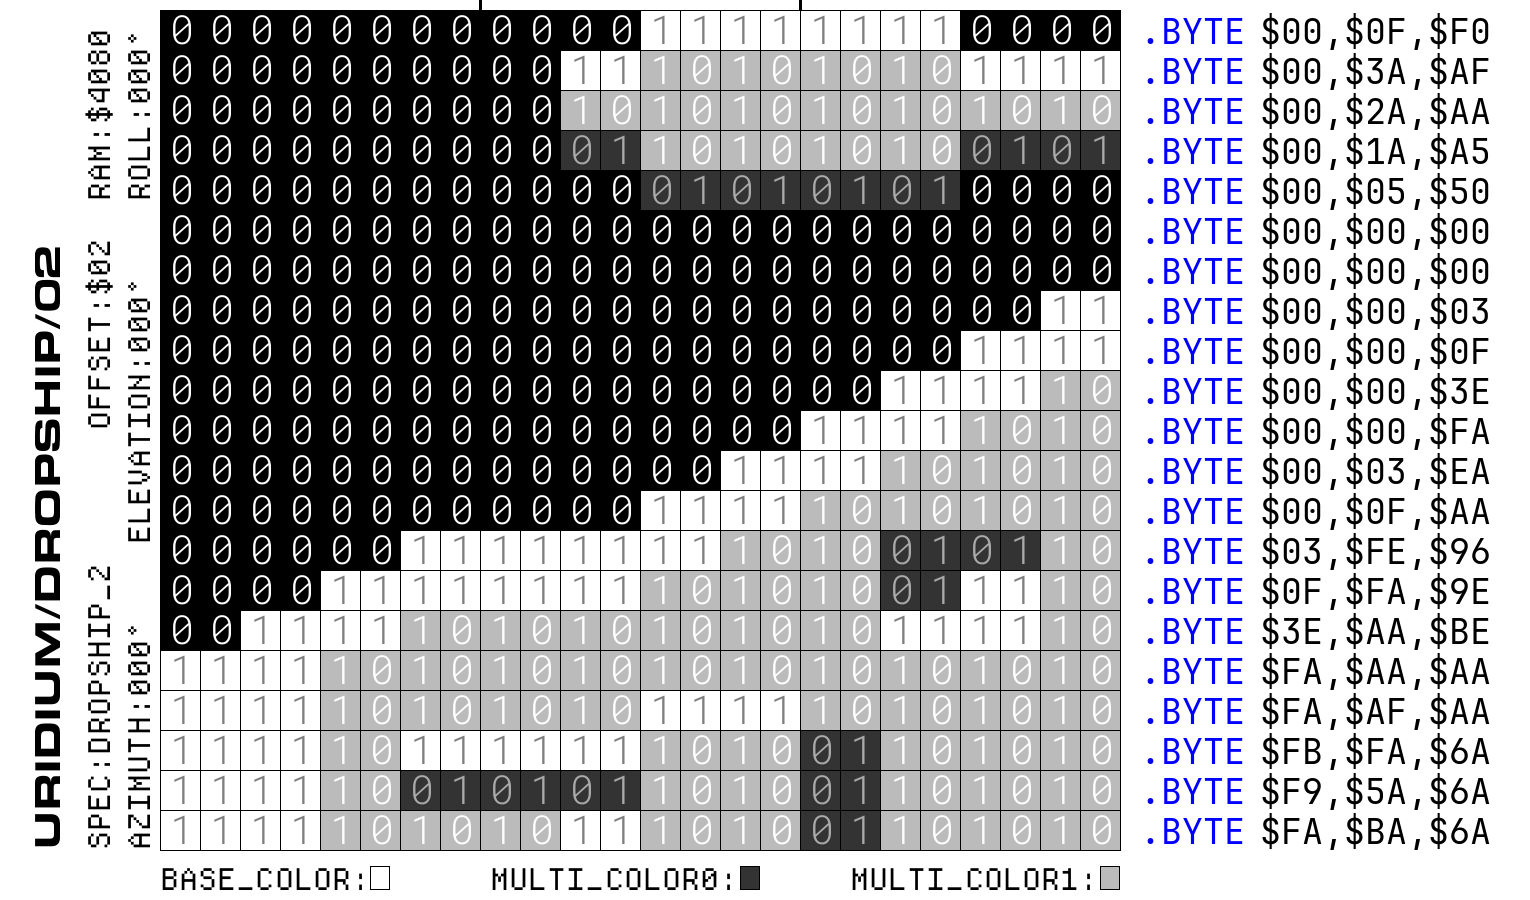

In [15]:
generateSpriteDiagram("DROPSHIP_2", 2)


In [16]:
for entry_num, sprite_name in enumerate(sprites_data):
    if not sprite_name:
        continue
    img = generateSpriteDiagram(sprite_name, entry_num)
    img.save(f"dropship_diagrams/{sprite_name}.png")
    img.save(f"dropship_diagrams_list/DROPSHIP_{entry_num}.png")

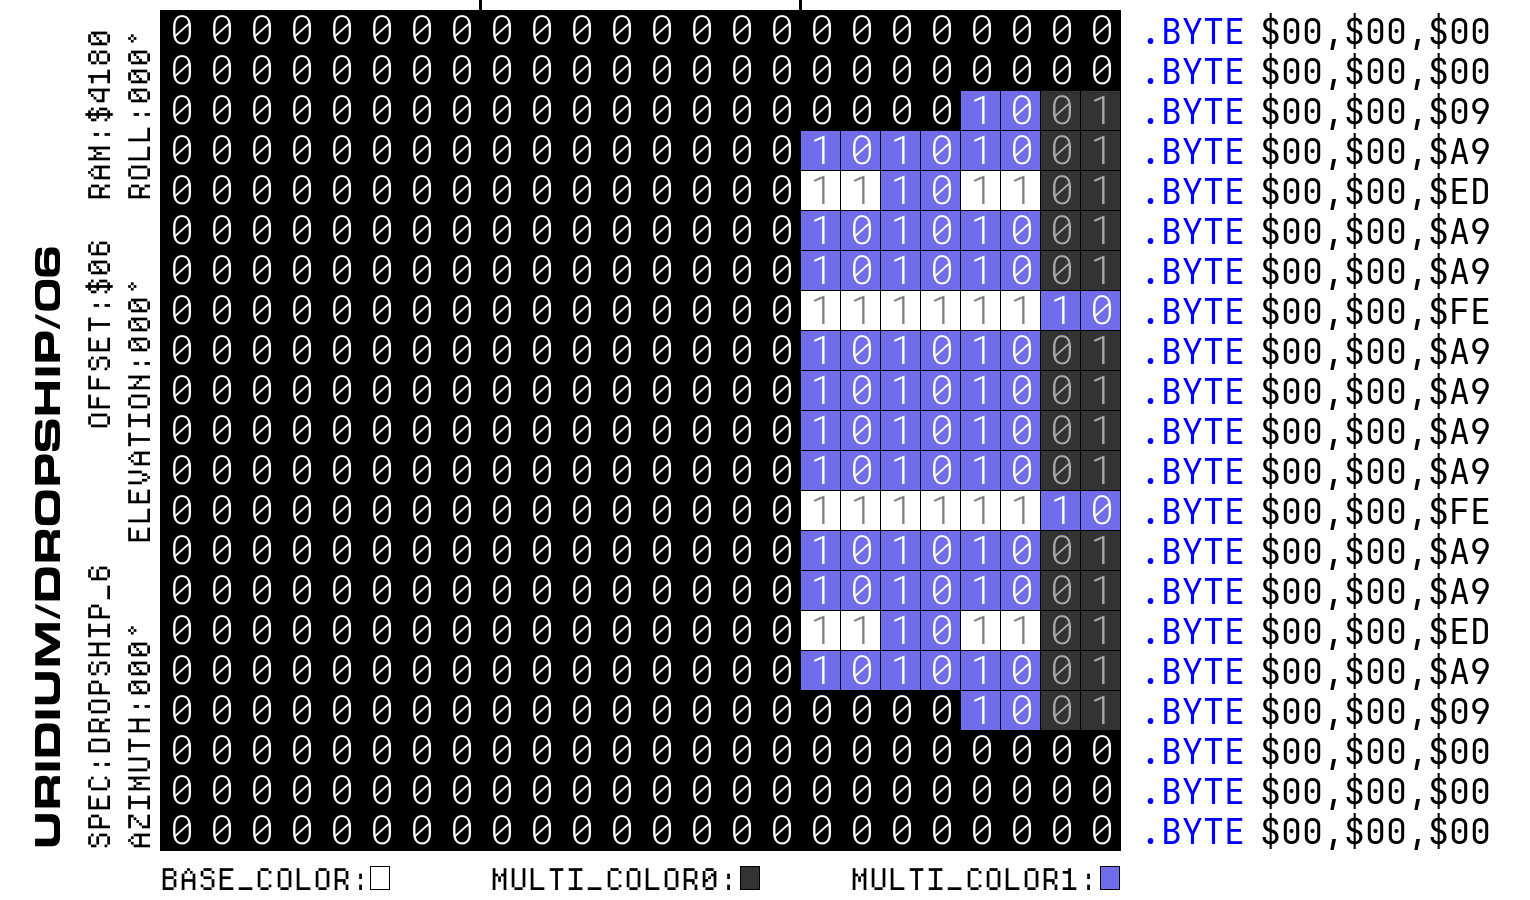

In [21]:
colors = (
    # cell color, text color
    ("c64_black", "white"),
    ("c64_gray1", "darkgray"),
    ("c64_white", "gray"),
    ("c64_ltblue", "white"),
)
sprite_name = "DROPSHIP_6"
entry_num = 6
img = generateSpriteDiagram(sprite_name, entry_num)
img.save(f"dropship_diagrams/{sprite_name}.png")
img.save(f"dropship_diagrams_list/DROPSHIP_{entry_num}.png")
img

###  Vertically Expanded Sprite Diagrams

In [227]:
colors = (
    # cell color, text color
    ("c64_black", "white"),
    ("c64_gray1", "darkgray"),
    ("c64_white", "gray"),
    ("c64_gray3", "white"),
)
sprite_name = "MANTA_LEFT_9"

def generateSpriteDiagramExpandVertical(sprite_name, entry_num):
    sprite_data = sprites_data[sprite_name]
    sprite_bytes = sprites_bytes[sprite_name]
    sprite_ram = sprites_ram[sprite_name]
    sprite_offset = sprites_offset[sprite_name]
    
    sprite_img = paintSprite(sprite_data, colors, verticalExpand=True)

    img = Image.new('RGBA', (1530,900))
    draw = ImageDraw.Draw(img)
    draw.rectangle([(0,0),img.size], fill = "white")

    # Sprite label
    label_text = f"URIDIUM/DROPSHIP/{('0'+str(entry_num))[-2:]}"
    label_fnt_size = 35
    label_fnt = ImageFont.truetype("Eurostile.ttf", label_fnt_size)
    txt_width = len(label_text) * label_fnt_size
    txt = Image.new('RGBA', (txt_width, label_fnt_size))
    draw = ImageDraw.Draw(txt)
    draw.rectangle([(0,0), txt.size], fill = "white")
    draw.text((0, 0), label_text, font=label_fnt, fill="black")
    label = txt.rotate(90,  expand=1)
    img.paste(label, (35,184))

    # Sprite spec name
    label_text = f"SPEC:{sprite_name.ljust(14)}   OFFSET:${sprite_offset.upper()}  RAM:${sprite_ram}"
    label_fnt_size = 30
    label_fnt = ImageFont.truetype("DepartureMono-Regular.otf", label_fnt_size)
    txt_width = len(label_text) * label_fnt_size
    txt = Image.new('RGBA', (txt_width, label_fnt_size+20))
    draw = ImageDraw.Draw(txt)
    draw.rectangle([(0,0), txt.size], fill = "white")
    draw.text((0, 0), label_text, font=label_fnt, fill="black")
    label = txt.rotate(90,  expand=1)
    img.paste(label, (80,-440))


    # Sprite orientation
    azimuth, roll, elevation = ("000","000","000")
    label_text = f"AZIMUTH:{azimuth}°    ELEVATION:{elevation}°    ROLL:{roll}°"
    label_fnt_size = 30
    label_fnt = ImageFont.truetype("DepartureMono-Regular.otf", label_fnt_size)
    txt_width = len(label_text) * label_fnt_size
    txt = Image.new('RGBA', (txt_width, label_fnt_size+20))
    draw = ImageDraw.Draw(txt)
    draw.rectangle([(0,0), txt.size], fill = "white")
    draw.text((0, 0), label_text, font=label_fnt, fill="black")
    label = txt.rotate(90,  expand=1)
    img.paste(label, (120,-440))

    # Sprite byte literals
    label_text = byte_literals
    label_fnt_size = 35
    label_fnt = ImageFont.truetype("JetBrainsMono-Regular.ttf", label_fnt_size)
    txt_width = len(label_text) * label_fnt_size
    txt_height =  len(sprite_bytes.split()) * (label_fnt_size+10)
    txt = Image.new('RGBA', (txt_width, txt_height))
    draw = ImageDraw.Draw(txt)
    draw.rectangle([(0,0), txt.size], fill = "white")
    draw.text((0, 0), label_text, font=label_fnt, fill="blue")
    label = txt
    img.paste(label, (640,8))

    # Sprite bytes
    label_text = sprite_bytes
    label_fnt_size = 35
    label_fnt = ImageFont.truetype("JetBrainsMono-Regular.ttf", label_fnt_size)
    txt_width = len(label_text) * label_fnt_size
    txt_height =  len(sprite_bytes.split()) * (label_fnt_size+10)
    txt = Image.new('RGBA', (txt_width, txt_height))
    draw = ImageDraw.Draw(txt)
    draw.rectangle([(0,0), txt.size], fill = "white")
    draw.text((0, 0), label_text, font=label_fnt, fill="black")
    label = txt
    img.paste(label, (760,8))

    # Color Label
    label_text = "BASE_COLOR: "
    label_fnt_size = 30
    label_fnt = ImageFont.truetype("DepartureMono-Regular.otf", label_fnt_size)
    txt_width = len(label_text) * (label_fnt_size - 10)
    txt = Image.new('RGBA', (txt_width, label_fnt_size))
    draw = ImageDraw.Draw(txt)
    draw.rectangle([(0,0), txt.size], fill = "white")
    draw.text((0, 0), label_text, font=label_fnt, fill="black")
    pixel_color = ImageColor.getrgb(c64_to_rgb[colors[2][0]])
    draw.rectangle([(210,6), (229,29)], fill = pixel_color, outline="black")
    label = txt
    img.paste(label, (160,860))

    # MultiCol0 Label
    label_text = "MULTI_COLOR0: "
    label_fnt_size = 30
    label_fnt = ImageFont.truetype("DepartureMono-Regular.otf", label_fnt_size)
    txt_width = len(label_text) * label_fnt_size
    txt = Image.new('RGBA', (txt_width, label_fnt_size))
    draw = ImageDraw.Draw(txt)
    draw.rectangle([(0,0), txt.size], fill = "white")
    draw.text((0, 0), label_text, font=label_fnt, fill="black")
    pixel_color = ImageColor.getrgb(c64_to_rgb[colors[1][0]])
    draw.rectangle([(250,6), (269,29)], fill = pixel_color, outline="black")
    label = txt
    img.paste(label, (490,860))

    # MultiCol1 Label
    label_text = "MULTI_COLOR1: "
    label_fnt_size = 30
    label_fnt = ImageFont.truetype("DepartureMono-Regular.otf", label_fnt_size)
    txt_width = len(label_text) * label_fnt_size
    txt = Image.new('RGBA', (txt_width, label_fnt_size))
    draw = ImageDraw.Draw(txt)
    draw.rectangle([(0,0), txt.size], fill = "white")
    draw.text((0, 0), label_text, font=label_fnt, fill="black")
    pixel_color = ImageColor.getrgb(c64_to_rgb[colors[3][0]])
    draw.rectangle([(250,6), (269,29)], fill = pixel_color, outline="black")
    label = txt
    img.paste(label, (850,860))

    # Main Sprite image
    sprite_img = sprite_img.resize((int(sprite_img.width / 2 ), int(sprite_img.height / 2)), Image.NEAREST)
    img.paste(sprite_img, (160,10))

    return img

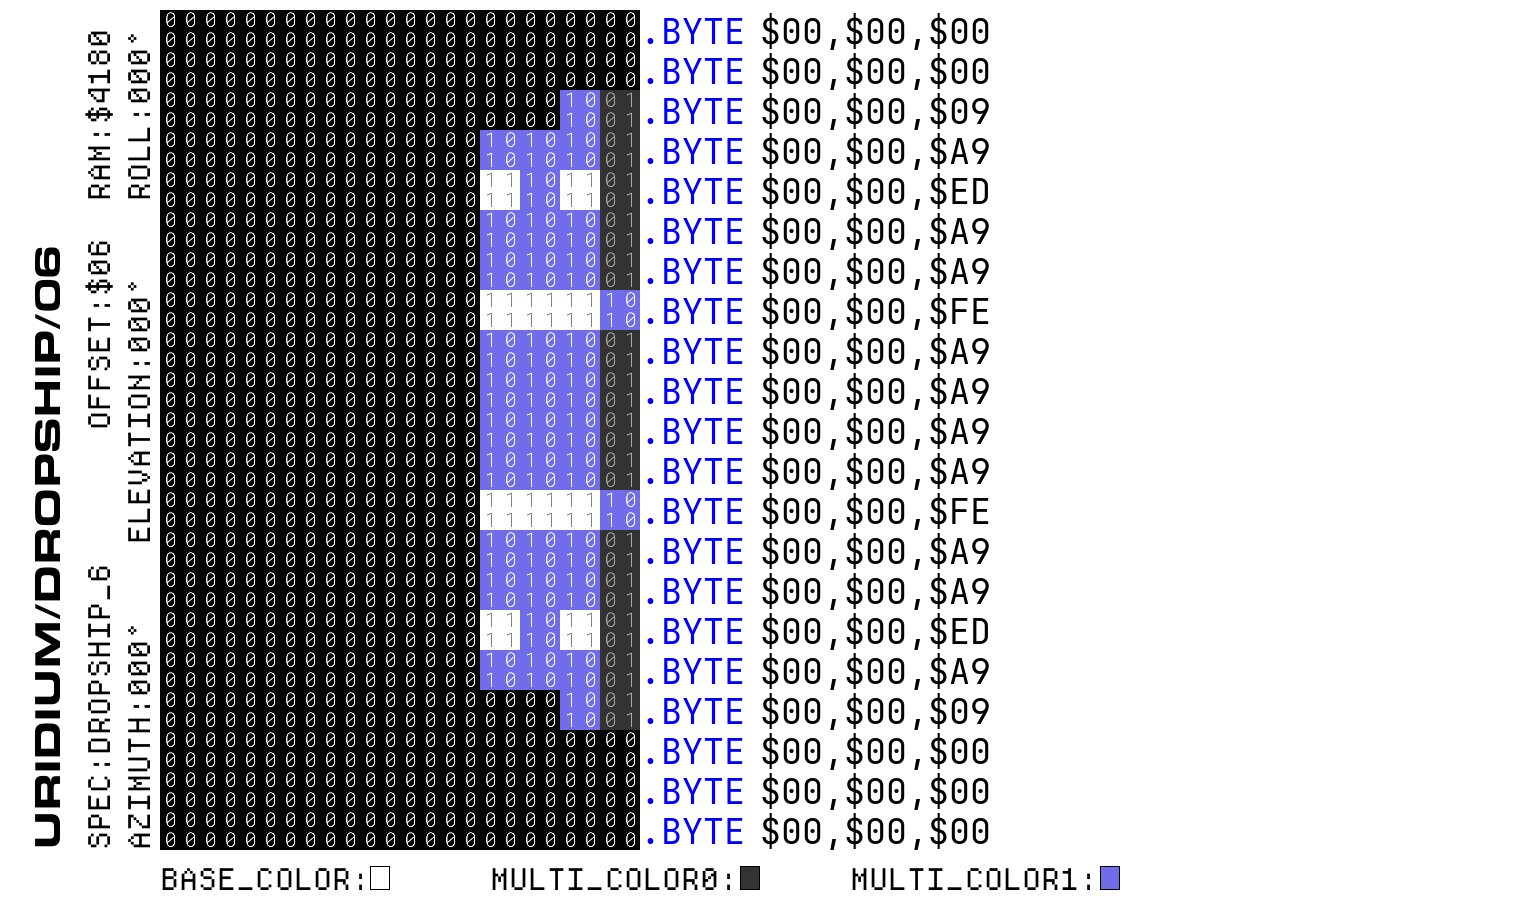

In [228]:
colors = (
    # cell color, text color
    ("c64_black", "white"),
    ("c64_gray1", "darkgray"),
    ("c64_white", "gray"),
    ("c64_ltblue", "white"),
)
sprite_name = "DROPSHIP_6"
generateSpriteDiagramExpandVertical(sprite_name, 6)


## Sprite Diagrams without Byte Literals

In [23]:
colors = (
    # cell color, text color
    ("c64_black", "white"),
    ("c64_gray1", "darkgray"),
    ("c64_white", "gray"),
    ("c64_gray3", "white"),
)

def generateSpriteDiagramWithoutByteLiterals(sprite_name, entry_num):
    sprite_data = sprites_data[sprite_name]
    sprite_bytes = sprites_bytes[sprite_name]
    sprite_ram = sprites_ram[sprite_name]
    sprite_offset = sprites_offset[sprite_name]
    
    sprite_img = paintSprite(sprite_data, colors)

    img = Image.new('RGBA', (1100,900))
    draw = ImageDraw.Draw(img)
    draw.rectangle([(0,0),img.size], fill = "white")

    # Sprite label
    label_text = f"URIDIUM/DROPSHIP/{('0'+str(entry_num))[-2:]}"
    label_fnt_size = 45
    label_fnt = ImageFont.truetype("Eurostile.ttf", label_fnt_size)
    txt_width = len(label_text) * label_fnt_size
    txt = Image.new('RGBA', (txt_width, label_fnt_size))
    draw = ImageDraw.Draw(txt)
    draw.rectangle([(0,0), txt.size], fill = "white")
    draw.text((0, 0), label_text, font=label_fnt, fill="black")
    label = txt.rotate(90,  expand=1)
    img.paste(label, (35,-10))

    # Sprite spec name
    label_text = f"SPEC:{sprite_name.ljust(14)}   OFFSET:${sprite_offset.upper()}  RAM:${sprite_ram}"
    label_fnt_size = 30
    label_fnt = ImageFont.truetype("DepartureMono-Regular.otf", label_fnt_size)
    txt_width = len(label_text) * label_fnt_size
    txt = Image.new('RGBA', (txt_width, label_fnt_size+20))
    draw = ImageDraw.Draw(txt)
    draw.rectangle([(0,0), txt.size], fill = "white")
    draw.text((0, 0), label_text, font=label_fnt, fill="black")
    label = txt.rotate(90,  expand=1)
    img.paste(label, (80,-440))

    # Color Label
    label_text = "BASE_COLOR: "
    label_fnt_size = 30
    label_fnt = ImageFont.truetype("DepartureMono-Regular.otf", label_fnt_size)
    txt_width = len(label_text) * (label_fnt_size - 10)
    txt = Image.new('RGBA', (txt_width, label_fnt_size))
    draw = ImageDraw.Draw(txt)
    draw.rectangle([(0,0), txt.size], fill = "white")
    draw.text((0, 0), label_text, font=label_fnt, fill="black")
    pixel_color = ImageColor.getrgb(c64_to_rgb[colors[2][0]])
    draw.rectangle([(210,6), (229,29)], fill = pixel_color, outline="black")
    label = txt
    img.paste(label, (120,860))

    # MultiCol0 Label
    label_text = "MULTI_COLOR0: "
    label_fnt_size = 30
    label_fnt = ImageFont.truetype("DepartureMono-Regular.otf", label_fnt_size)
    txt_width = len(label_text) * label_fnt_size
    txt = Image.new('RGBA', (txt_width, label_fnt_size))
    draw = ImageDraw.Draw(txt)
    draw.rectangle([(0,0), txt.size], fill = "white")
    draw.text((0, 0), label_text, font=label_fnt, fill="black")
    pixel_color = ImageColor.getrgb(c64_to_rgb[colors[1][0]])
    draw.rectangle([(250,6), (269,29)], fill = pixel_color, outline="black")
    label = txt
    img.paste(label, (450,860))

    # MultiCol1 Label
    label_text = "MULTI_COLOR1: "
    label_fnt_size = 30
    label_fnt = ImageFont.truetype("DepartureMono-Regular.otf", label_fnt_size)
    txt_width = len(label_text) * label_fnt_size
    txt = Image.new('RGBA', (txt_width, label_fnt_size))
    draw = ImageDraw.Draw(txt)
    draw.rectangle([(0,0), txt.size], fill = "white")
    draw.text((0, 0), label_text, font=label_fnt, fill="black")
    pixel_color = ImageColor.getrgb(c64_to_rgb[colors[3][0]])
    draw.rectangle([(250,6), (269,29)], fill = pixel_color, outline="black")
    label = txt
    img.paste(label, (810,860))

    # Main Sprite image
    img.paste(sprite_img, (120,10))

    # Byte delimiter ticks
    draw = ImageDraw.Draw(img)
    vectors = [
        ((480,0), (480,10)), 
        ((800,0), (800,10)),
        #((450,850), (450,865)), 
        #((770,850), (770,865)),
    ]
    for start,end in vectors:
        draw.line((start,end), width=3, fill="black")
    return img

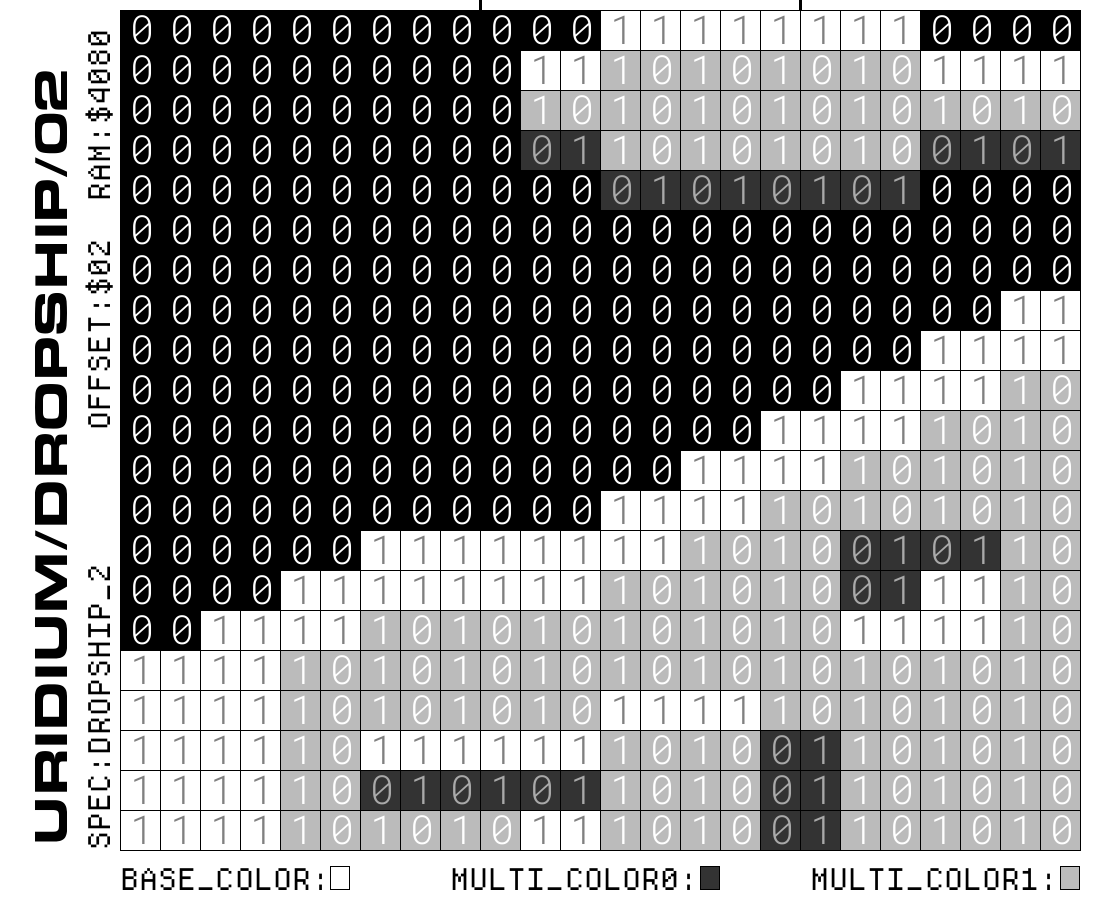

In [24]:
generateSpriteDiagramWithoutByteLiterals("DROPSHIP_2", 2)


In [25]:
for entry_num, sprite_name in enumerate(sprites_data):
    if not sprite_name:
        continue
    img = generateSpriteDiagramWithoutByteLiterals(sprite_name, entry_num)
    img.save(f"dropship_diagrams/{sprite_name}_BARE.png")
    img.save(f"dropship_diagrams_list/DROPSHIP_BARE_{entry_num}.png")

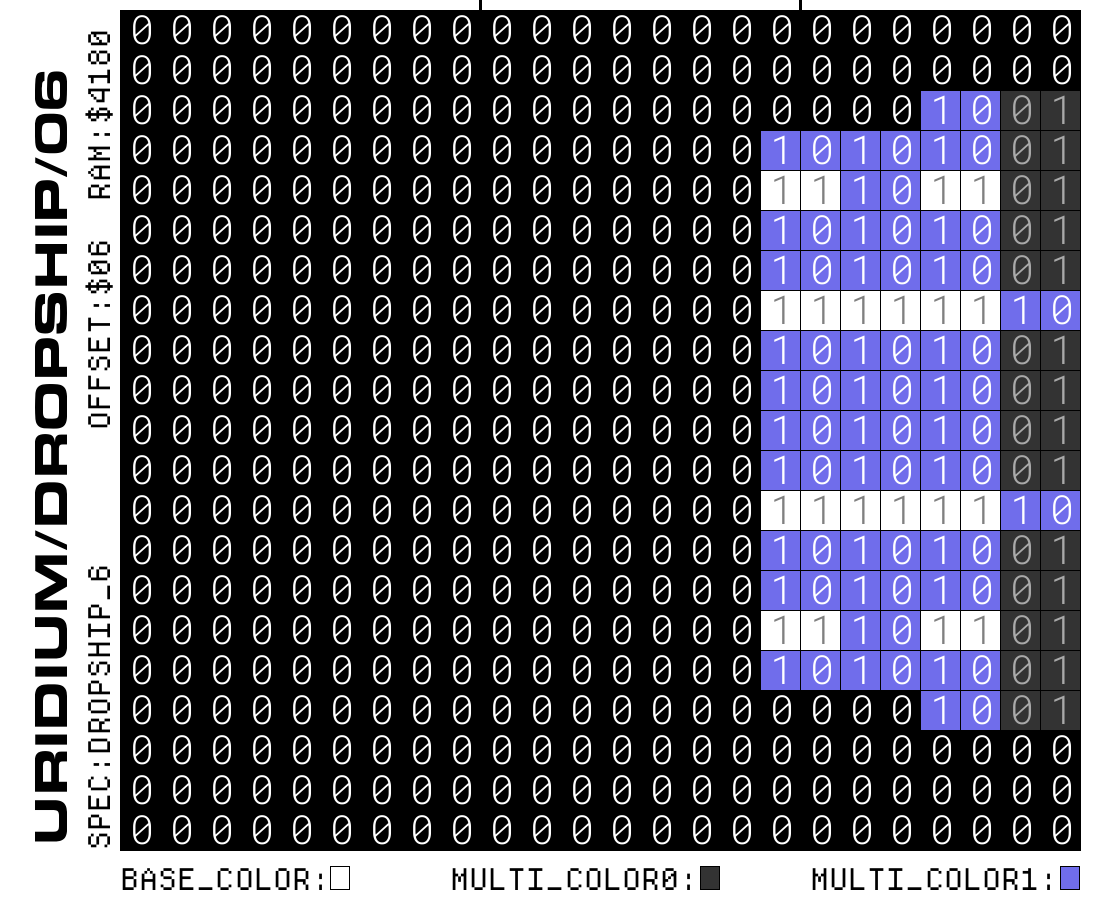

In [26]:
colors = (
    # cell color, text color
    ("c64_black", "white"),
    ("c64_gray1", "darkgray"),
    ("c64_white", "gray"),
    ("c64_ltblue", "white"),
)
sprite_name = "DROPSHIP_6"
entry_num = 6
img = generateSpriteDiagramWithoutByteLiterals(sprite_name, entry_num)
img.save(f"dropship_diagrams/{sprite_name}_BARE.png")
img.save(f"dropship_diagrams_list/DROPSHIP_BARE_{entry_num}.png")
img

In [159]:
colors = (
    # cell color, text color
    ("c64_black", "white"),
    ("c64_gray1", "darkgray"),
    ("c64_white", "gray"),
    ("c64_gray3", "white"),
)

def generateSpriteDiagramWithoutByteLiteralsVerticalExpand(sprite_name, entry_num):
    sprite_data = sprites_data[sprite_name]
    sprite_bytes = sprites_bytes[sprite_name]
    sprite_ram = sprites_ram[sprite_name]
    sprite_offset = sprites_offset[sprite_name]
    
    sprite_img = paintSprite(sprite_data, colors, verticalExpand=True)

    img = Image.new('RGBA', (620,870))
    draw = ImageDraw.Draw(img)
    draw.rectangle([(0,0),img.size], fill = "white")

    # Sprite label
    label_text = f"URIDIUM/DROPSHIP/{('0'+str(entry_num))[-2:]}"
    label_fnt_size = 45
    label_fnt = ImageFont.truetype("Eurostile.ttf", label_fnt_size)
    txt_width = len(label_text) * label_fnt_size
    txt = Image.new('RGBA', (txt_width, label_fnt_size))
    draw = ImageDraw.Draw(txt)
    draw.rectangle([(0,0), txt.size], fill = "white")
    draw.text((0, 0), label_text, font=label_fnt, fill="black")
    label = txt.rotate(90,  expand=1)
    img.paste(label, (35,-10))

    # Sprite spec name
    label_text = f"SPEC:{sprite_name.ljust(14)}   OFFSET:${sprite_offset.upper()}  RAM:${sprite_ram}"
    label_fnt_size = 30
    label_fnt = ImageFont.truetype("DepartureMono-Regular.otf", label_fnt_size)
    txt_width = len(label_text) * label_fnt_size
    txt = Image.new('RGBA', (txt_width, label_fnt_size+20))
    draw = ImageDraw.Draw(txt)
    draw.rectangle([(0,0), txt.size], fill = "white")
    draw.text((0, 0), label_text, font=label_fnt, fill="black")
    label = txt.rotate(90,  expand=1)
    img.paste(label, (80,-440))

    # Main Sprite image
    sprite_img = sprite_img.resize((int(sprite_img.width / 2 ), int(sprite_img.height / 2)), Image.NEAREST)
    img.paste(sprite_img, (120,10))

    return img

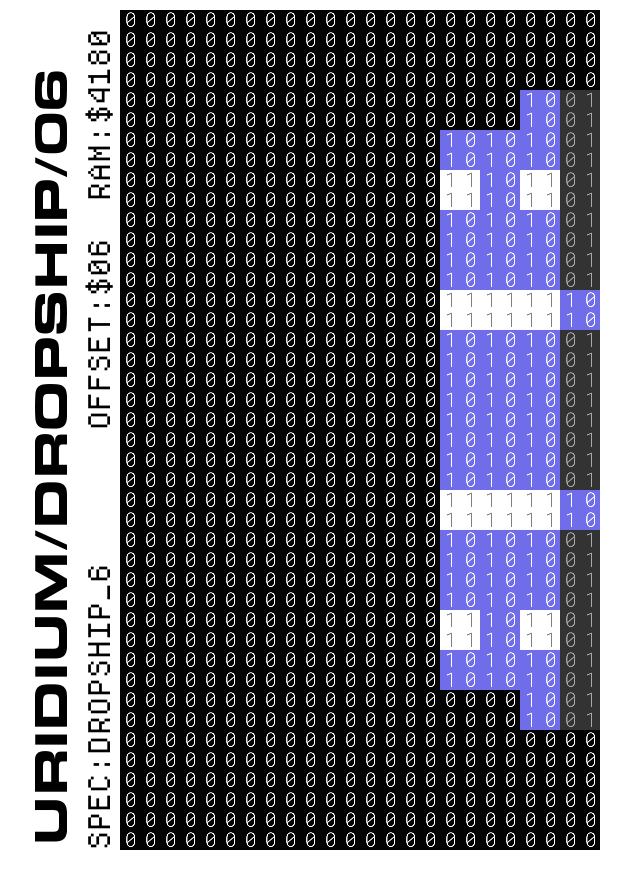

In [161]:
colors = (
    # cell color, text color
    ("c64_black", "white"),
    ("c64_gray1", "darkgray"),
    ("c64_white", "gray"),
    ("c64_ltblue", "white"),
)
sprite_name = "DROPSHIP_6"
entry_num = 6
img = generateSpriteDiagramWithoutByteLiteralsVerticalExpand(sprite_name, entry_num)
img.save(f"dropship_diagrams/{sprite_name}_BARE.png")
img.save(f"dropship_diagrams_list/DROPSHIP_BARE_EXPANDED_{entry_num}.png")
img

### Diagrams without Byte literals and labels on right

In [27]:
colors = (
    # cell color, text color
    ("c64_black", "white"),
    ("c64_gray1", "darkgray"),
    ("c64_white", "gray"),
    ("c64_gray3", "white"),
)

def generateSpriteDiagramWithoutByteLiteralsLabelRight(sprite_name, entry_num):
    sprite_data = sprites_data[sprite_name]
    sprite_bytes = sprites_bytes[sprite_name]
    sprite_ram = sprites_ram[sprite_name]
    sprite_offset = sprites_offset[sprite_name]
    
    sprite_img = paintSprite(sprite_data, colors)

    img = Image.new('RGBA', (1100,900))
    draw = ImageDraw.Draw(img)
    draw.rectangle([(0,0),img.size], fill = "white")

    # Sprite label
    label_text = f"URIDIUM/DROPSHIP/{('0'+str(entry_num))[-2:]}"
    label_fnt_size = 45
    label_fnt = ImageFont.truetype("Eurostile.ttf", label_fnt_size)
    txt_width = len(label_text) * label_fnt_size
    txt = Image.new('RGBA', (txt_width, label_fnt_size))
    draw = ImageDraw.Draw(txt)
    draw.rectangle([(0,0), txt.size], fill = "white")
    draw.text((0, 0), label_text, font=label_fnt, fill="black")
    label = txt.rotate(-90,  expand=1)
    img.paste(label, (1020, 10))

    # Sprite spec name
    label_text = f"SPEC:{sprite_name.ljust(14)}   OFFSET:${sprite_offset.upper()}  RAM:${sprite_ram}"
    label_fnt_size = 30
    label_fnt = ImageFont.truetype("DepartureMono-Regular.otf", label_fnt_size)
    txt_width = len(label_text) * label_fnt_size
    txt = Image.new('RGBA', (txt_width, label_fnt_size+20))
    draw = ImageDraw.Draw(txt)
    draw.rectangle([(0,0), txt.size], fill = "white")
    draw.text((0, 0), label_text, font=label_fnt, fill="black")
    label = txt.rotate(-90,  expand=1)
    img.paste(label, (970, 10))

    # Color Label
    label_text = "BASE_COLOR: "
    label_fnt_size = 30
    label_fnt = ImageFont.truetype("DepartureMono-Regular.otf", label_fnt_size)
    txt_width = len(label_text) * (label_fnt_size - 10)
    txt = Image.new('RGBA', (txt_width, label_fnt_size))
    draw = ImageDraw.Draw(txt)
    draw.rectangle([(0,0), txt.size], fill = "white")
    draw.text((0, 0), label_text, font=label_fnt, fill="black")
    pixel_color = ImageColor.getrgb(c64_to_rgb[colors[2][0]])
    draw.rectangle([(210,6), (229,29)], fill = pixel_color, outline="black")
    label = txt
    img.paste(label, (10,860))

    # MultiCol0 Label
    label_text = "MULTI_COLOR0: "
    label_fnt_size = 30
    label_fnt = ImageFont.truetype("DepartureMono-Regular.otf", label_fnt_size)
    txt_width = len(label_text) * label_fnt_size
    txt = Image.new('RGBA', (txt_width, label_fnt_size))
    draw = ImageDraw.Draw(txt)
    draw.rectangle([(0,0), txt.size], fill = "white")
    draw.text((0, 0), label_text, font=label_fnt, fill="black")
    pixel_color = ImageColor.getrgb(c64_to_rgb[colors[1][0]])
    draw.rectangle([(250,6), (269,29)], fill = pixel_color, outline="black")
    label = txt
    img.paste(label, (350,860))

    # MultiCol1 Label
    label_text = "MULTI_COLOR1: "
    label_fnt_size = 30
    label_fnt = ImageFont.truetype("DepartureMono-Regular.otf", label_fnt_size)
    txt_width = len(label_text) * label_fnt_size
    txt = Image.new('RGBA', (txt_width, label_fnt_size))
    draw = ImageDraw.Draw(txt)
    draw.rectangle([(0,0), txt.size], fill = "white")
    draw.text((0, 0), label_text, font=label_fnt, fill="black")
    pixel_color = ImageColor.getrgb(c64_to_rgb[colors[3][0]])
    draw.rectangle([(250,6), (269,29)], fill = pixel_color, outline="black")
    label = txt
    img.paste(label, (710,860))

    # Main Sprite image
    img.paste(sprite_img, (10,10))

    """
    # Byte delimiter ticks
    draw = ImageDraw.Draw(img)
    vectors = [
        ((480,0), (480,10)), 
        ((800,0), (800,10)),
        #((450,850), (450,865)), 
        #((770,850), (770,865)),
    ]
    for start,end in vectors:
        draw.line((start,end), width=3, fill="black")
    """
    return img

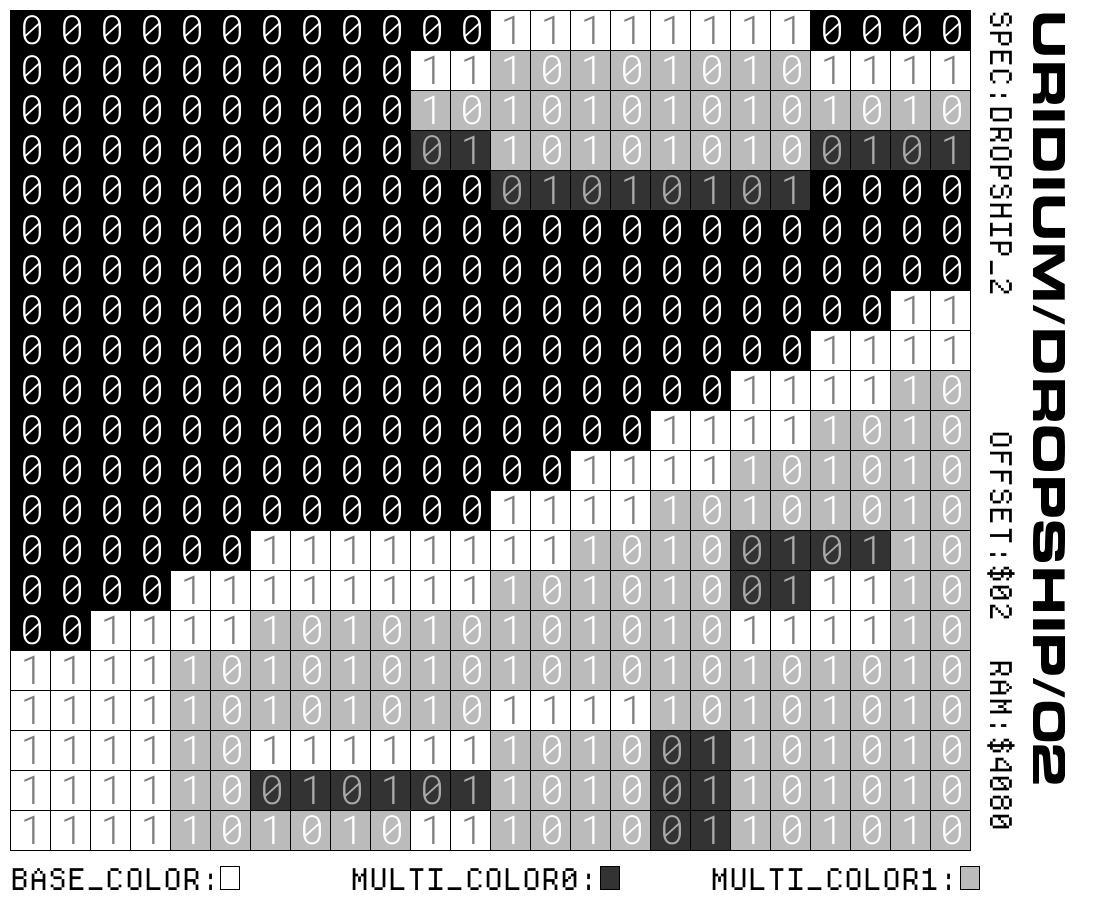

In [195]:
generateSpriteDiagramWithoutByteLiteralsLabelRight("DROPSHIP_2", 2)


In [188]:
for entry_num, sprite_name in enumerate(sprites_data):
    if not sprite_name:
        continue
    img = generateSpriteDiagramWithoutByteLiteralsLabelRight(sprite_name, entry_num)
    img.save(f"dropship_diagrams/{sprite_name}_BARE_LABEL_RIGHT.png")
    img.save(f"dropship_diagrams_list/DROPSHIP_BARE_{entry_num}_LABEL_RIGHT.png")

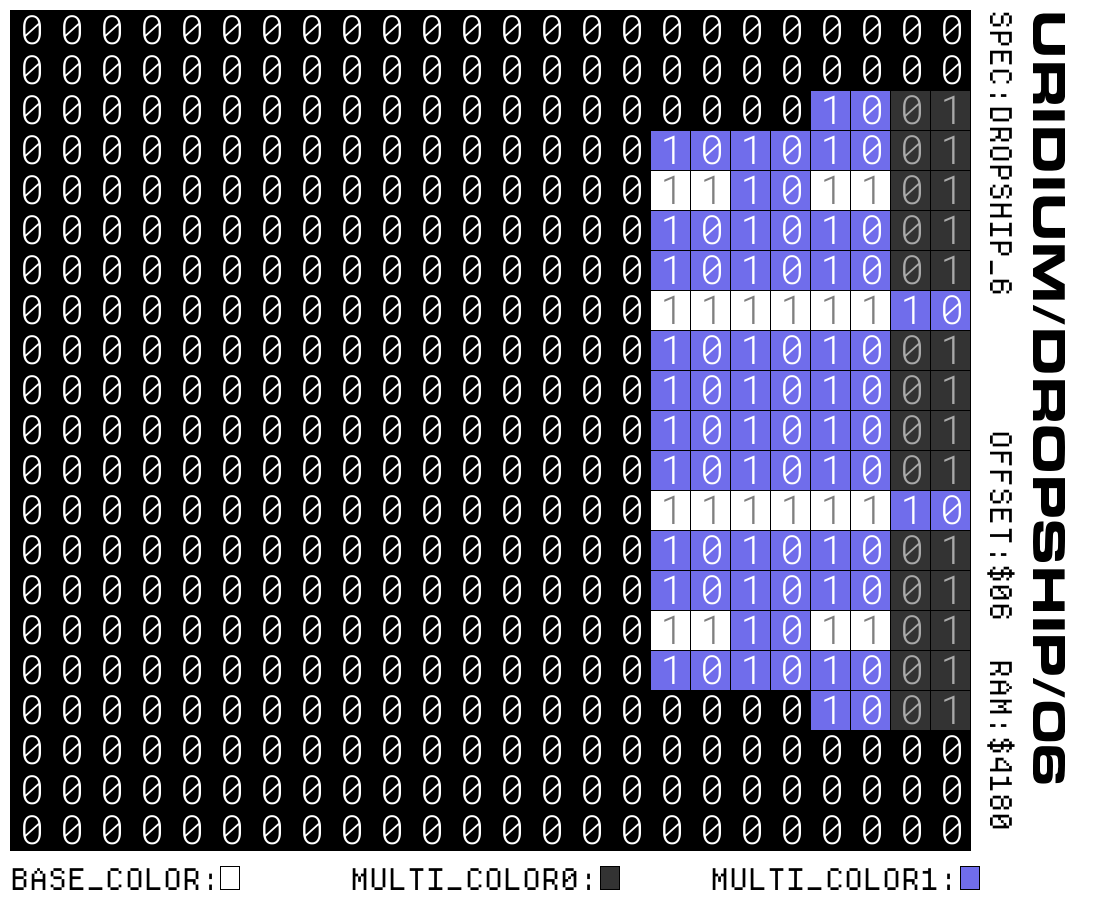

In [28]:
colors = (
    # cell color, text color
    ("c64_black", "white"),
    ("c64_gray1", "darkgray"),
    ("c64_white", "gray"),
    ("c64_ltblue", "white"),
)
sprite_name = "DROPSHIP_6"
entry_num = 6
img = generateSpriteDiagramWithoutByteLiteralsLabelRight(sprite_name, entry_num)
img.save(f"dropship_diagrams/{sprite_name}_BARE_LABEL_RIGHT.png")
img.save(f"dropship_diagrams_list/DROPSHIP_BARE_{entry_num}_LABEL_RIGHT.png")
img

In [136]:
colors = (
    # cell color, text color
    ("c64_black", "white"),
    ("c64_gray1", "darkgray"),
    ("c64_white", "gray"),
    ("c64_gray3", "white"),
)

def generateSpriteDiagramWithoutByteLiteralsLabelRightVerticalExpand(sprite_name, entry_num):
    sprite_data = sprites_data[sprite_name]
    sprite_bytes = sprites_bytes[sprite_name]
    sprite_ram = sprites_ram[sprite_name]
    sprite_offset = sprites_offset[sprite_name]
    
    sprite_img = paintSprite(sprite_data, colors, verticalExpand=True, transparentBackground=True)

    img = Image.new('RGBA', (600,840))
    draw = ImageDraw.Draw(img)
    draw.rectangle([(0,0),img.size], fill = "white")

    # Sprite label
    label_text = f"URIDIUM/DROPSHIP/{('0'+str(entry_num))[-2:]}"
    label_fnt_size = 45
    label_fnt = ImageFont.truetype("Eurostile.ttf", label_fnt_size)
    txt_width = len(label_text) * label_fnt_size
    txt = Image.new('RGBA', (txt_width, label_fnt_size))
    draw = ImageDraw.Draw(txt)
    draw.rectangle([(0,0), txt.size], fill = "white")
    draw.text((0, 0), label_text, font=label_fnt, fill="black")
    label = txt.rotate(-90,  expand=1)
    img.paste(label, (540, 10))

    # Sprite spec name
    label_text = f"SPEC:{sprite_name.ljust(14)}   OFFSET:${sprite_offset.upper()}  RAM:${sprite_ram}"
    label_fnt_size = 28
    label_fnt = ImageFont.truetype("DepartureMono-Regular.otf", label_fnt_size)
    txt_width = len(label_text) * label_fnt_size
    txt = Image.new('RGBA', (txt_width, label_fnt_size+20))
    draw = ImageDraw.Draw(txt)
    draw.rectangle([(0,0), txt.size], fill = "white")
    draw.text((0, 0), label_text, font=label_fnt, fill="black")
    label = txt.rotate(-90,  expand=1)
    img.paste(label, (490, 10))

    # Main Sprite image
    sprite_img = sprite_img.resize((int(sprite_img.width / 2 ), int(sprite_img.height / 2)), Image.NEAREST)
    img.paste(sprite_img, (0,0))

    """
    # Byte delimiter ticks
    draw = ImageDraw.Draw(img)
    vectors = [
        ((480,0), (480,10)), 
        ((800,0), (800,10)),
        #((450,850), (450,865)), 
        #((770,850), (770,865)),
    ]
    for start,end in vectors:
        draw.line((start,end), width=3, fill="black")
    """
    return img

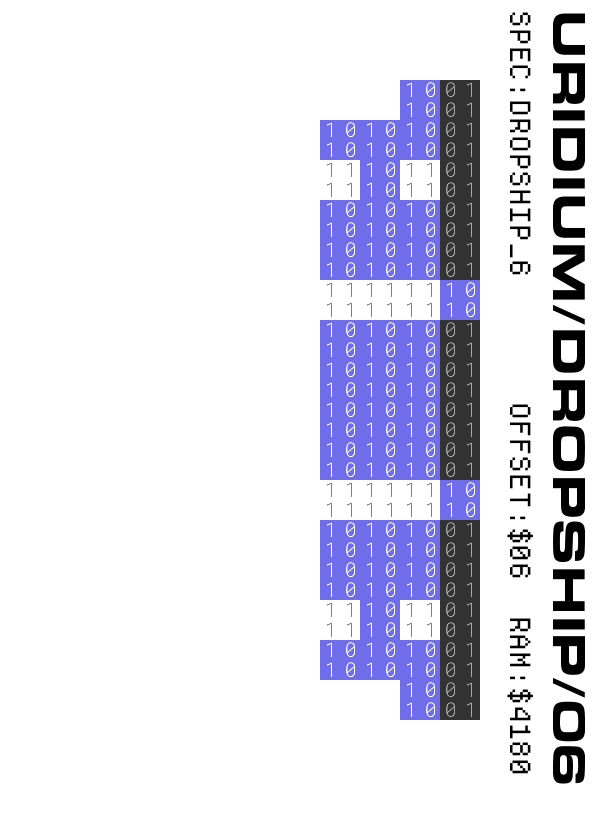

In [137]:
colors = (
    # cell color, text color
    ("c64_black", "white"),
    ("c64_gray1", "darkgray"),
    ("c64_white", "gray"),
    ("c64_ltblue", "white"),
)
sprite_name = "DROPSHIP_6"
entry_num = 6
img = generateSpriteDiagramWithoutByteLiteralsLabelRightVerticalExpand(sprite_name, entry_num)
img.save(f"dropship_diagrams/{sprite_name}_BARE_LABEL_RIGHT.png")
img.save(f"dropship_diagrams_list/DROPSHIP_BARE_{entry_num}_LABEL_RIGHT.png")
img

### Create Rear of Dropship with Bay Doors Diagram - No Expansion

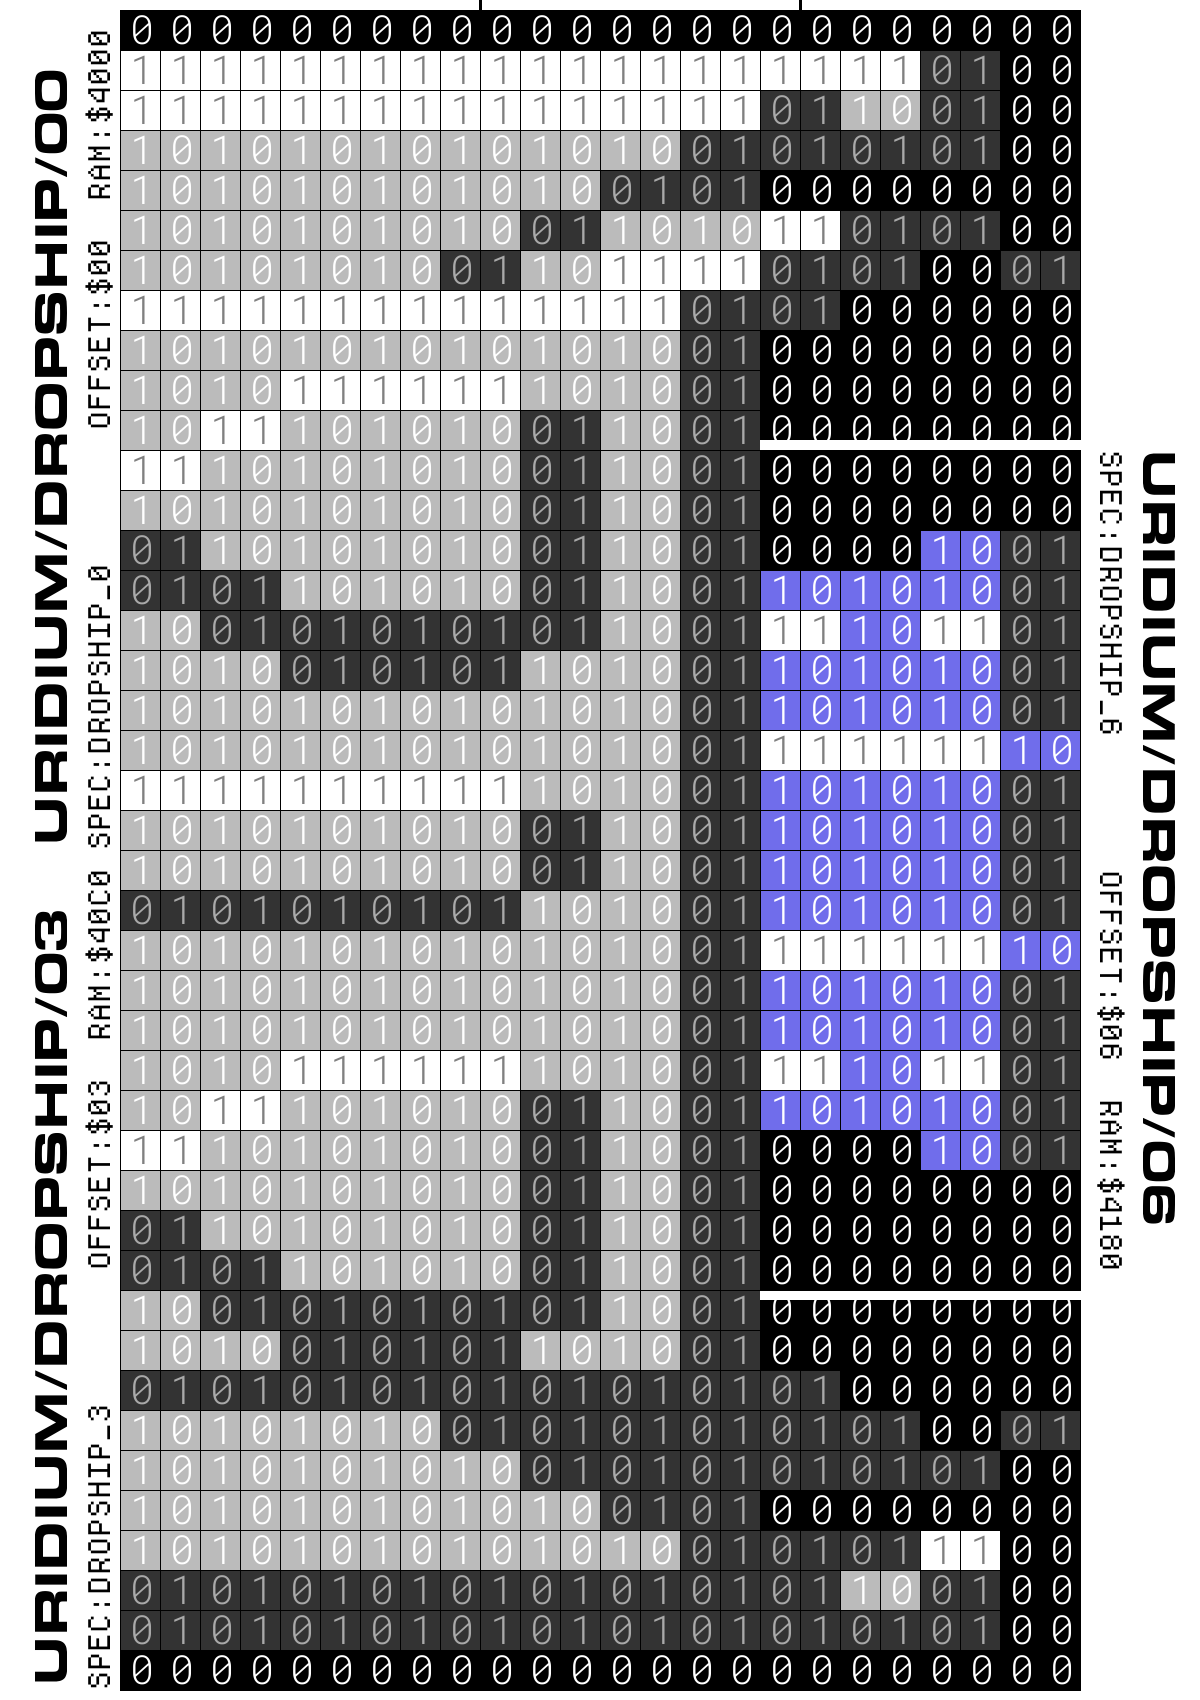

In [30]:

img = Image.new( 'RGB', (1200,1700),color="white")

colors = (
    # cell color, text color
    ("c64_black", "white"),
    ("c64_gray1", "darkgray"),
    ("c64_white", "gray"),
    ("c64_gray3", "white"),
)
sprite_img = generateSpriteDiagramWithoutByteLiterals("DROPSHIP_0", 0)
img.paste(sprite_img,(0,0))
sprite_img = generateSpriteDiagramWithoutByteLiterals("DROPSHIP_3", 3)
sprite_img = sprite_img.crop((0,10,1100,900))
img.paste(sprite_img,(0,850))

colors = (
    # cell color, text color
    ("c64_black", "white"),
    ("c64_gray1", "darkgray"),
    ("c64_white", "gray"),
    ("c64_ltblue", "white"),
)
sprite_img = generateSpriteDiagramWithoutByteLiteralsLabelRight("DROPSHIP_6", 6)
sprite_img = sprite_img.crop((650,0,1100,860))
img.paste(sprite_img,(760,440))

img.save(f"dropship_diagrams/dropship_baydoor.png")
img

### Create Rear of Dropship with Bay Doors Diagram - With Vertical Expansion

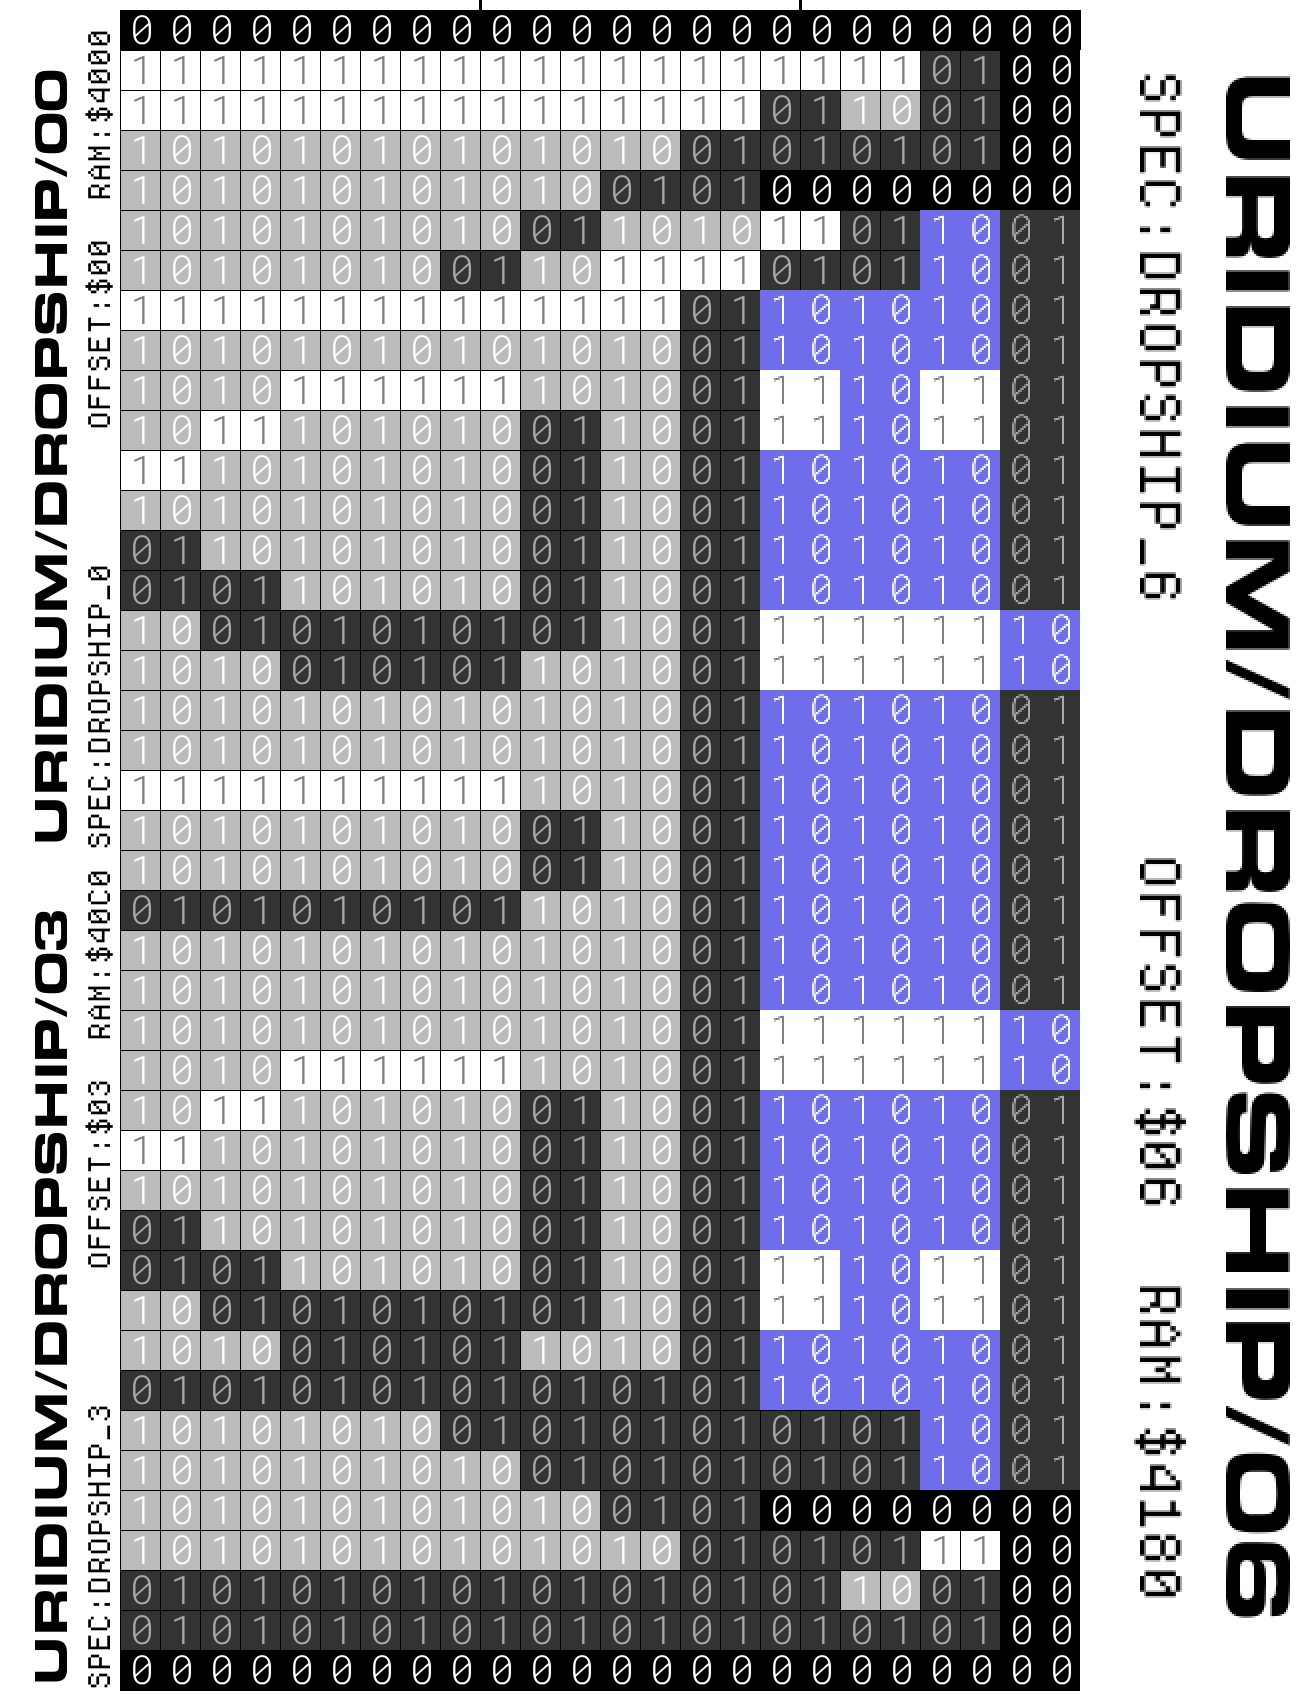

In [139]:

img = Image.new( 'RGB', (1300,1700),color="white")

colors = (
    # cell color, text color
    ("c64_black", "white"),
    ("c64_gray1", "darkgray"),
    ("c64_white", "gray"),
    ("c64_gray3", "white"),
)
sprite_img = generateSpriteDiagramWithoutByteLiterals("DROPSHIP_0", 0)
img.paste(sprite_img,(0,0))
sprite_img = generateSpriteDiagramWithoutByteLiterals("DROPSHIP_3", 3)
sprite_img = sprite_img.crop((0,10,1100,900))
img.paste(sprite_img,(0,850))

colors = (
    # cell color, text color
    ("c64_black", "white"),
    ("c64_gray1", "darkgray"),
    ("c64_white", "gray"),
    ("c64_ltblue", "white"),
)
sprite_img = generateSpriteDiagramWithoutByteLiteralsLabelRightVerticalExpand("DROPSHIP_6", 6)
sprite_img = sprite_img.crop((305,0,600,860))
sprite_img = sprite_img.resize((int(sprite_img.width * 2 ), int(sprite_img.height * 2)), Image.NEAREST)
img.paste(sprite_img,(730,50),mask=sprite_img)

img.save(f"dropship_diagrams/dropship_baydoor_scaled.png")
img

### Raw Sprites

In [222]:
from PIL import Image, ImageColor
SPRITE_COLS = 24
SPRITE_ROWS = 21
CELL_WIDTH = 40
CELL_HEIGHT = 40

def paintRawSprite(sprite, colors, verticalExpand=False):
    multicol0, multicol1,color = colors
    
    verticalExpansion = 2 if verticalExpand else 1
    SPRITE_COLS = 24
    SPRITE_ROWS = 21 * verticalExpansion

    colormap = {
        "01": multicol0,
        "10": color,
        "11": multicol1,
    }
    
    if sprite not in sprites_data:
        print(sprite)
        return
    
    image_width = SPRITE_COLS
    image_height = SPRITE_ROWS
    img = Image.new( 'RGBA', (image_width+1, image_height+1))
    pixels = img.load()

    bit_array = sprites_data[sprite]
    if verticalExpand:
        expanded_bit_array = []
        for a in bit_array:
            expanded_bit_array += [a,a]
        bit_array = expanded_bit_array
    
    for y, l in enumerate(bit_array):
        for x,bit in enumerate(l):
            if bit == "00":
                continue
            pixel_color = ImageColor.getrgb(c64_to_rgb[colormap[bit]])
            pixels[x,y] = pixel_color
    return img


### Write out the raw sprites

In [200]:
colors = (
    # cell color, text color
    "c64_gray1",
    "c64_white",
    "c64_gray3",
)
sprite_images = []
for sprite_name in dict(list(sprites_data.items())[:6]):
    img = paintRawSprite(sprite_name, colors)
    sprite_images += [img]
    if sprite_name:
        img.save(f"dropship_sprites/{sprite_name}.png")

colors = (
    # cell color, text color
    "c64_gray1",
    "c64_white",
    "c64_ltblue",
)
for sprite_name in dict(list(sprites_data.items())[6:]):
    img = paintRawSprite(sprite_name, colors)
    sprite_images += [img]
    if sprite_name:
        img.save(f"dropship_sprites/{sprite_name}.png")


### Composite the dropship from constituent sprites

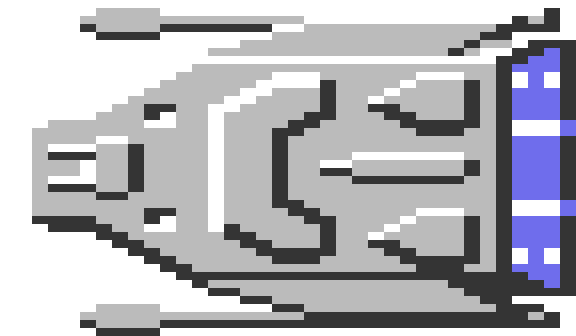

In [233]:
img = Image.new( 'RGBA', (72,42))
origin = (0,0)
x,y = 0,0

colors = (
    # cell color, text color
    "c64_gray1",
    "c64_white",
    "c64_ltblue",
)
sprite_image = paintRawSprite("DROPSHIP_6", colors, verticalExpand=True)
#sprite_image = sprite_image.resize((sprite_image.width, sprite_image.height * 2), Image.NEAREST)
img.paste(sprite_image,(48,1),mask=sprite_image)

for sprite_image in reversed(sprite_images[3:6] + sprite_images[:3]):
    img.paste(sprite_image,(x,y),mask=sprite_image)
    x += 24
    if x > 71:
        y+=21
        x = 0

img = img.resize((img.width * 8, img.height * 8), Image.NEAREST)
img.save(f"dropship_sprites/dropship.png")
img

###  Gradual composition of drop ship

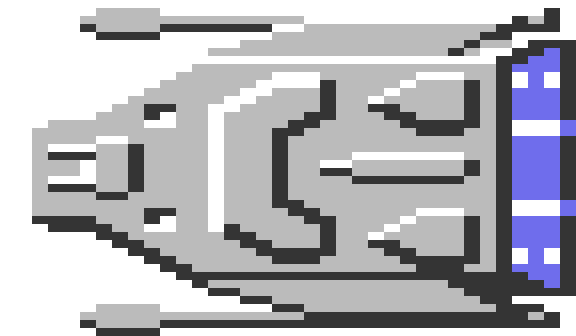

In [226]:
img = Image.new( 'RGBA', (72,42))
origin = (0,0)
x,y = 0,0

default_colors = (
    # cell color, text color
    "c64_gray1",
    "c64_white",
    "c64_gray3",
)
deck_colors = (
    # cell color, text color
    "c64_gray1",
    "c64_white",
    "c64_ltblue",
)
ordered_sprites = [
    ("DROPSHIP_6", 48,  1, True,  deck_colors),
    ("DROPSHIP_3", 48, 21, False, default_colors),
    ("DROPSHIP_4", 24, 21, False, default_colors),
    ("DROPSHIP_5",  0, 21, False, default_colors),
    ("DROPSHIP_2",  0,  0, False, default_colors),
    ("DROPSHIP_1", 24,  0, False, default_colors),
    ("DROPSHIP_0", 48,  0, False, default_colors),
]

for i, (sprite_name, x, y, verticalExpand, colors) in enumerate(ordered_sprites):
    sprite_image = paintRawSprite(sprite_name, colors, verticalExpand=verticalExpand)
    img.paste(sprite_image,(x,y),mask=sprite_image)
    gradual_img = img.resize((img.width * 8, img.height * 8), Image.NEAREST)
    gradual_img.save(f"dropship_sprites/dropship_gradual_{i}.png")

gradual_img

# Scratchpad